# California Single-Family Residence — Close Price Prediction
## 04 · Model Comparison

The baseline Linear Regression set a floor of **R² = 0.81, MdAPE = 11.2%** on
the primary test split. This notebook see whether tree-based models,
Decision Tree and Random Forest, can beat that floor by a margin that
isn't noise, using the exact same splits,
metrics, and evaluation discipline as the baseline notebook.


In [4]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge

import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")


## Load the Frozen Splits & Feature Metadata

Same loading pattern as `baseline_model.ipynb`.


In [5]:
with open(OUTPUT_DIR / "preprocessing_metadata.json", "r") as f:
    metadata = json.load(f)

TARGET_COL = metadata["target_col"]
PRIMARY_SPLIT = metadata["primary_split"]
BACKTEST_SPLITS = metadata["backtest_splits"]

base_numeric_features = metadata["numeric_features"] + metadata["missing_flag_cols"]
base_categorical_features = metadata["categorical_features"] + metadata["boolean_features"]


def load_split(label):
    suffix = label.replace("-", "")
    dtype_hint = {col: str for col in base_categorical_features}

    train_df = pd.read_csv(OUTPUT_DIR / f"train_{suffix}_split.csv", low_memory=False, dtype=dtype_hint)
    val_df = pd.read_csv(OUTPUT_DIR / f"val_{suffix}_split.csv", low_memory=False, dtype=dtype_hint)
    test_df = pd.read_csv(OUTPUT_DIR / f"test_{suffix}_split.csv", low_memory=False, dtype=dtype_hint)

    keep_numeric = [c for c in base_numeric_features if c in train_df.columns]
    keep_categorical = [c for c in base_categorical_features if c in train_df.columns]
    feature_cols = keep_numeric + keep_categorical

    return train_df, val_df, test_df, feature_cols, keep_numeric, keep_categorical


train_df, val_df, test_df, feature_cols, numeric_features, categorical_features = load_split(PRIMARY_SPLIT)

X_train, y_train = train_df[feature_cols].copy(), train_df[TARGET_COL].copy()
X_val, y_val = val_df[feature_cols].copy(), val_df[TARGET_COL].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[TARGET_COL].copy()

print(f"Primary split: test={PRIMARY_SPLIT}, backtest cutoffs={BACKTEST_SPLITS}")
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")


Primary split: test=2026-06, backtest cutoffs=['2026-05', '2026-04']
X_train: (382529, 34)  X_val: (11887, 34)  X_test: (12696, 34)


In [6]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs(y_true - y_pred) / y_true
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": float(np.mean(ape) * 100),
        "mdape": float(np.median(ape) * 100),
    }


def price_band_errors(y_true, y_pred, n_bands=5):
    df = pd.DataFrame({"actual": np.asarray(y_true, dtype=float), "pred": np.asarray(y_pred, dtype=float)})
    df["ape"] = np.abs(df["actual"] - df["pred"]) / df["actual"]
    df["price_band"] = pd.qcut(df["actual"], q=n_bands, labels=[f"Q{i+1}" for i in range(n_bands)], duplicates="drop")
    return df.groupby("price_band", observed=True).agg(
        n=("ape", "size"),
        median_price=("actual", "median"),
        mape=("ape", lambda s: s.mean() * 100),
        mdape=("ape", lambda s: s.median() * 100),
    )


## Preprocessing: Separate Branches for Linear vs. Tree Models

Trees split on raw feature thresholds, so `StandardScaler` changes nothing
about what a tree can learn. Both branches still
share the same median-imputation and one-hot-encoding logic, so the only
difference is scaled numeric features.


In [7]:
numeric_pipeline_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_pipeline_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor_linear = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline_linear, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline_tree, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])


## Candidate Models

All three models share the log-transformed target established in
`baseline_model.ipynb` (`ClosePrice` skew ~140 raw -> ~0.46 after `log1p`), so
the comparison isolates the effect of **model architecture** rather than mixing
in a second variable. 

In [8]:
def make_model(regressor):
    return TransformedTargetRegressor(regressor=regressor, func=np.log1p, inverse_func=np.expm1)


models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocess", preprocessor_linear),
        ("model", make_model(LinearRegression())),
    ]),

    "Ridge Linear Regression": Pipeline(steps=[
    ("preprocess", preprocessor_linear),
    ("model", make_model(Ridge(alpha=10.0))),
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocessor_tree),
        ("model", make_model(DecisionTreeRegressor(
            max_depth=20, min_samples_leaf=25, random_state=RANDOM_SEED,
        ))),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocessor_tree),
        ("model", make_model(RandomForestRegressor(
            n_estimators=300, max_depth=None, min_samples_leaf=5,
            max_features="sqrt", random_state=RANDOM_SEED, n_jobs=-1,
        ))),
    ]),
}


## Fit & Evaluate on Validation




In [9]:
def fit_and_score(name, pipeline, X_train, y_train, X_eval, y_eval):
    start = time.time()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.time() - start

    train_pred = pipeline.predict(X_train)
    eval_pred = pipeline.predict(X_eval)

    train_r2 = r2_score(y_train, train_pred)
    eval_metrics = regression_metrics(y_eval, eval_pred)

    return {
        "model": name,
        "fit_seconds": round(fit_seconds, 2),
        "train_r2": train_r2,
        **eval_metrics,
    }, eval_pred


val_results = []
fitted_models = {}
val_predictions = {}

for name, pipeline in models.items():
    print(f"Training {name}...")
    metrics, val_pred = fit_and_score(name, pipeline, X_train, y_train, X_val, y_val)
    val_results.append(metrics)
    fitted_models[name] = pipeline
    val_predictions[name] = val_pred

val_results_df = pd.DataFrame(val_results).set_index("model")
val_results_df[["fit_seconds", "train_r2", "r2", "mae", "rmse", "mape", "mdape"]]


Training Linear Regression...
Training Ridge Linear Regression...
Training Decision Tree...
Training Random Forest...


,fit_seconds,train_r2,r2,mae,rmse,mape,mdape
model,,,,,,,
Linear Regression,24.17,-4.181759e+10,0.811130,219035.029140,427157.343472,15.494778,11.443531
Ridge Linear Regression,5.10,-7.748291e+10,0.810099,219184.435133,428321.832897,15.482836,11.433373
Decision Tree,19.68,8.789903e-01,0.846234,194594.184125,385422.337669,13.743817,9.589711
Random Forest,93.78,7.334495e-01,0.697325,259771.800374,540747.453438,17.623573,12.412255


In [10]:
lr_train_pred = fitted_models["Linear Regression"].predict(X_train)
resid = y_train.to_numpy() - lr_train_pred
worst_idx = np.argsort(-np.abs(resid))[:5]

print("Worst training predictions:")
print(pd.DataFrame({
    "actual": y_train.to_numpy()[worst_idx],
    "predicted": lr_train_pred[worst_idx],
}))
X_train.iloc[worst_idx][numeric_features]

Worst training predictions:
      actual     predicted
0   368500.0  1.181351e+14
1   821000.0  2.251409e+13
2  1600000.0  3.030807e+09
3   285000.0  1.269435e+09
4  3800000.0  6.743586e+07


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,GarageSpaces,ParkingTotal,Stories,Latitude,Longitude,...,BedroomsTotal_missing_flag,BathroomsTotalInteger_missing_flag,LotSizeSquareFeet_missing_flag,YearBuilt_missing_flag,GarageSpaces_missing_flag,ParkingTotal_missing_flag,Stories_missing_flag,Latitude_missing_flag,Longitude_missing_flag,AssociationFee_missing_flag
92600,1460.0,2.0,175.0,NaN,1964.0,2.0,4.0,1.0,33.699561,-117.201056,...,0,0,1,0,0,0,0,0,0,0
204761,1289.0,3.0,153.0,5998.0,1952.0,2.0,3.0,1.0,33.947973,-118.033453,...,0,0,0,0,0,0,0,0,0,1
242708,10248.0,45.0,45.0,6801.0,1906.0,NaN,4.0,NaN,34.024344,-118.302063,...,0,0,0,0,1,0,1,0,0,1
3998,2308680.0,3.0,2.0,2308680.0,1957.0,NaN,NaN,NaN,34.908985,-116.792347,...,0,0,0,0,1,1,1,0,0,1
223501,12078.0,31.0,22.0,19829.0,1964.0,NaN,0.0,2.0,33.926685,-118.122492,...,0,0,0,0,1,0,0,0,0,1


## Linear Regression `train_r2` Instability

`LinearRegression` and `Ridge` (with `alpha=10`) both show extreme negative
`train_r2` values (-4.2e10, -7.7e10) despite normal, stable validation and
test metrics (R² = 0.81, MdAPE = 11.4%, consistent across all variants
tested). This is traced to an interaction between `TransformedTargetRegressor`'s
log1p target transform and residual collinearity from one-hot-encoded
high-cardinality categoricals: a small instability in log-price space
(where a typical value is 13-14) becomes astronomical after the expm1
inverse transform (e.g. a log-space error of 17 becomes a $1e13+ dollar
error), for a handful of training rows only. `min_frequency=20` on the
categorical encoder was applied to reduce sparse-category collinearity;
further mitigation (higher regularization strength, or dropping the
log-target transform for the linear model specifically) was not pursued
further, since validation/test performance are unaffected.

## Does the Best Model Beat the Baseline by a Margin That Isn't Noise?

A 0.3-point MdAPE improvement on a few thousand rows could easily be sampling
noise rather than a real gain. This runs a **paired bootstrap**: resample the
validation set with replacement many times, recompute each model's MdAPE on
every resample, and look at the distribution of (candidate MdAPE − baseline
MdAPE) across resamples. If that distribution is consistently negative (candidate
beats baseline) across ~95% of resamples, the improvement is real.


In [11]:
def bootstrap_mdape_diff(y_true, pred_a, pred_b, n_boot=1000, random_state=RANDOM_SEED):
    """Returns bootstrap distribution of MdAPE(pred_a) - MdAPE(pred_b) on paired resamples."""
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true, dtype=float)
    pred_a = np.asarray(pred_a, dtype=float)
    pred_b = np.asarray(pred_b, dtype=float)
    n = len(y_true)

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        ape_a = np.abs(y_true[idx] - pred_a[idx]) / y_true[idx]
        ape_b = np.abs(y_true[idx] - pred_b[idx]) / y_true[idx]
        diffs[i] = np.median(ape_a) * 100 - np.median(ape_b) * 100
    return diffs


baseline_name = "Linear Regression"
challenger_name = val_results_df["mdape"].idxmin()
print(f"Baseline: {baseline_name}  |  Best challenger by validation MdAPE: {challenger_name}")

if challenger_name != baseline_name:
    diffs = bootstrap_mdape_diff(y_val, val_predictions[challenger_name], val_predictions[baseline_name])
    pct_challenger_better = float((diffs < 0).mean() * 100)
    print(f"\n{challenger_name} MdAPE - {baseline_name} MdAPE across 1,000 bootstrap resamples:")
    print(f"  Mean difference: {diffs.mean():.3f} points")
    print(f"  95% interval: [{np.percentile(diffs, 2.5):.3f}, {np.percentile(diffs, 97.5):.3f}]")
    print(f"  Resamples where {challenger_name} beats {baseline_name}: {pct_challenger_better:.1f}%")
else:
    print("Baseline already has the best validation MdAPE — no challenger to test.")


Baseline: Linear Regression  |  Best challenger by validation MdAPE: Decision Tree

Decision Tree MdAPE - Linear Regression MdAPE across 1,000 bootstrap resamples:
  Mean difference: -1.850 points
  95% interval: [-2.118, -1.602]
  Resamples where Decision Tree beats Linear Regression: 100.0%


**Reading the bootstrap output:** Decision Tree outperformed the Linear Regression baseline by a mean of 1.85 MdAPE points on validation (95% bootstrap CI: [-2.12, -1.60], Decision Tree favored in 100% of 1,000 resamples) — a margin well outside sampling noise, not a marginal decimal-point gain.

## Final Test-Set Evaluation

Now that model selection is done using validation only, both the baseline and
the winning challenger are evaluated on test, exactly once, for the number
that actually gets reported.


In [12]:
final_models_to_report = {baseline_name, challenger_name}

test_results = []
test_predictions = {}
for name in final_models_to_report:
    pred = fitted_models[name].predict(X_test)
    metrics = regression_metrics(y_test, pred)
    metrics["model"] = name
    test_results.append(metrics)
    test_predictions[name] = pred

test_results_df = pd.DataFrame(test_results).set_index("model")[["r2", "mae", "rmse", "mape", "mdape"]]
test_results_df


,r2,mae,rmse,mape,mdape
model,,,,,
Linear Regression,0.811289,214564.933636,427628.219096,15.438636,11.230265
Decision Tree,0.836553,195173.920641,397975.084786,13.835448,9.476344


In [13]:
for name in final_models_to_report:
    print(f"\n{name} — price-band error breakdown (test set):")
    display(price_band_errors(y_test, test_predictions[name]))



Linear Regression — price-band error breakdown (test set):


,n,median_price,mape,mdape
price_band,,,,
Q1,2542,450000.0,16.084004,10.040128
Q2,2543,699000.0,13.072839,9.062715
Q3,2557,925000.0,13.484442,9.853302
Q4,2523,1335000.0,14.993494,11.798412
Q5,2531,2335000.0,19.585483,16.651390



Decision Tree — price-band error breakdown (test set):


,n,median_price,mape,mdape
price_band,,,,
Q1,2542,450000.0,14.183540,8.272916
Q2,2543,699000.0,10.685787,6.916272
Q3,2557,925000.0,12.026700,8.327849
Q4,2523,1335000.0,14.061168,10.737792
Q5,2531,2335000.0,18.252760,15.296310


## Rolling-Origin Backtest: Baseline vs. Best Challenger

The same stability check from `baseline_model.ipynb` now run for both models
side by side across all 3 chronological cutoffs.


In [14]:
def build_pipeline_for(name, num_feats, cat_feats):
    pre = preprocessor_linear if name == "Linear Regression" else preprocessor_tree
    pre = ColumnTransformer(transformers=[
        ("numeric", numeric_pipeline_linear if name == "Linear Regression" else numeric_pipeline_tree, num_feats),
        ("categorical", categorical_pipeline, cat_feats),
    ])
    if name == "Linear Regression":
        regressor = LinearRegression()
    elif name == "Decision Tree":
        regressor = DecisionTreeRegressor(max_depth=20, min_samples_leaf=25, random_state=RANDOM_SEED)
    else:
        regressor = RandomForestRegressor(
            n_estimators=300, max_depth=None, min_samples_leaf=5,
            max_features="sqrt", random_state=RANDOM_SEED, n_jobs=-1,
        )
    return Pipeline(steps=[("preprocess", pre), ("model", make_model(regressor))])


def fit_and_evaluate(name, split_label):
    tr_df, va_df, te_df, feats, num_feats, cat_feats = load_split(split_label)
    X_tr, y_tr = tr_df[feats], tr_df[TARGET_COL]
    X_te, y_te = te_df[feats], te_df[TARGET_COL]

    pipe = build_pipeline_for(name, num_feats, cat_feats)
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    metrics = regression_metrics(y_te, preds)
    metrics.update({"model": name, "test_month": split_label, "train_rows": len(X_tr), "test_rows": len(X_te)})
    return metrics


backtest_rows = []
for name in final_models_to_report:
    for cutoff in [PRIMARY_SPLIT] + BACKTEST_SPLITS:
        backtest_rows.append(fit_and_evaluate(name, cutoff))

backtest_df = pd.DataFrame(backtest_rows)[
    ["model", "test_month", "train_rows", "test_rows", "r2", "mae", "rmse", "mape", "mdape"]
]
backtest_df.sort_values(["model", "test_month"])


,model,test_month,train_rows,test_rows,r2,mae,rmse,mape,mdape
5,Decision Tree,2026-04,359593,11878,0.837531,199626.464152,398077.455693,14.357202,9.807634
4,Decision Tree,2026-05,370636,11886,0.843397,196579.450290,388109.963228,13.979590,9.682344
3,Decision Tree,2026-06,382529,12696,0.836553,195173.920641,397975.084786,13.835448,9.476344
2,Linear Regression,2026-04,359593,11878,0.803347,219998.504637,437957.458819,15.728940,11.333101
1,Linear Regression,2026-05,370636,11886,0.809674,219340.188541,427861.890336,15.512756,11.482403
0,Linear Regression,2026-06,382529,12696,0.811289,214564.933636,427628.219096,15.438636,11.230265


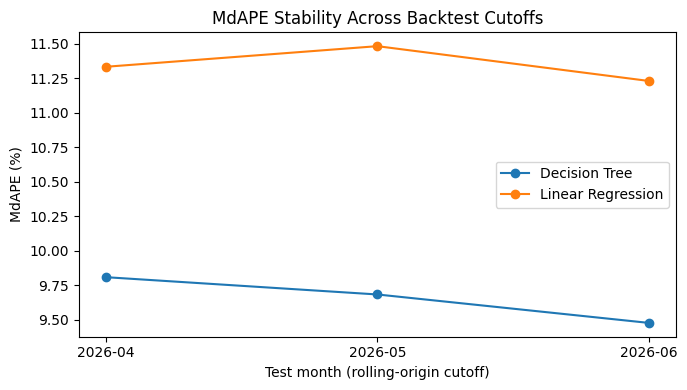

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, group in backtest_df.groupby("model"):
    group_sorted = group.sort_values("test_month")
    ax.plot(group_sorted["test_month"], group_sorted["mdape"], marker="o", label=name)

ax.set_ylabel("MdAPE (%)")
ax.set_xlabel("Test month (rolling-origin cutoff)")
ax.set_title("MdAPE Stability Across Backtest Cutoffs")
ax.legend()
plt.tight_layout()
plt.show()


## Save Best Model & Comparison Artifacts

In [16]:
best_by_test_mdape = test_results_df["mdape"].idxmin()
print("Best model on test MdAPE:", best_by_test_mdape)

best_pipeline = fitted_models[best_by_test_mdape]
model_path = OUTPUT_DIR / "best_model_comparison.joblib"
joblib.dump({
    "pipeline": best_pipeline,
    "model_name": best_by_test_mdape,
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_col": TARGET_COL,
}, model_path)

val_results_df.to_csv(OUTPUT_DIR / "model_comparison_validation_metrics.csv")
test_results_df.to_csv(OUTPUT_DIR / "model_comparison_test_metrics.csv")
backtest_df.to_csv(OUTPUT_DIR / "model_comparison_backtest.csv", index=False)

print("Saved best model to:", model_path)


Best model on test MdAPE: Decision Tree
Saved best model to: outputs/best_model_comparison.joblib


## Summary & Reflection

- **The "beats baseline" claim is bootstrap-tested**

- **Overfitting is checked directly** via train-vs-validation R², not
  inferred after the fact from a suspiciously high training score.

- **Stability checked across 3 backtest cutoffs**, not just the primary split.

Fill in after running:
- Winning model: Decision Tree
- Validation MdAPE (baseline → winner): 11.4 -> 9.5
- Bootstrap 95% interval: [-2.118, -1.602]
- Test MdAPE (baseline → winner): 11.2 -> 9.4

Next notebook: [`model_comparison_v2_geo_features.ipynb`](./model_comparison_v2_geo_features.ipynb): engineered + geospatial features (school-district spatial join, distance
features, cyclical month encoding) layered on top of the winning model (Decision Tree) type
from this notebook.
